# Financial Transaction Fraud Detection Using Machine Learning and Explainable AI
### An End-to-End Fraud Detection and Risk Scoring Framework for Digital Transactions
**Course:** MBA / Master of Science in Data Science & Business Analytics  
**Capstone Project:** Financial Risk Analytics & Machine Learning Systems  
**Primary Dataset:** Transaction Fraud Detection Dataset (50,000 Verified Transactions)  
**Author / Data Science Team:** Risk Analytics & Applied AI Group  
**Reproducibility Seed:** `RANDOM_STATE = 42`

---

## Executive Summary
In digital banking, instant payment systems, and e-commerce platforms, financial institutions process millions of transactions daily. Only a minuscule proportion—typically under 2%—constitute fraudulent activity. This creates an extreme **class imbalance** problem where naive models achieve 98%+ accuracy by simply approving all transactions, while completely failing to detect actual financial crime.

This project develops an operational, end-to-end Machine Learning and Explainable AI (XAI) framework that:
1. **Identifies suspicious transactions** using supervised algorithms (Logistic Regression, Decision Trees, Random Forests, XGBoost, LightGBM) and unsupervised anomaly detection (Isolation Forest).
2. **Systematically benchmarks class imbalance solutions** (Baseline unweighted vs. Cost-sensitive class weighting vs. SMOTE resampling).
3. **Optimizes the decision threshold** beyond the arbitrary 0.50 cutoff, maximizing fraud recall while minimizing false alarms.
4. **Translates probabilities into an Operational Fraud Risk Score (0–100)** mapped into a 3-tier Business Decision Engine (*Approve*, *Step-Up Authentication*, *Block & Investigate*).
5. **Provides transaction-level Explainable AI** using SHAP (SHapley Additive exPlanations) to explain feature-level risk drivers to fraud analysts and regulators.
6. **Prioritizes high-risk alerts** using an Expected Loss model ($	ext{Probability} 	imes 	ext{Amount}$).
7. **Simulates bottom-line financial P&L impact**, quantifying fraud loss prevented versus operational review costs.

## 1. Business Problem & Cost-Sensitive Risk Framework

Financial institutions face an asymmetric cost structure when evaluating payment transactions:

$$\begin{array}{|c|c|c|}
\hline
\textbf{Actual / Predicted} & \textbf{Predicted Legitimate (0)} & \textbf{Predicted Fraud (1)} \\
\hline
\textbf{Actual Legitimate (0)} & \textbf{True Negative (TN)}: Clean Approval & \textbf{False Positive (FP)}: False Alarm / Friction \\
\hline
\textbf{Actual Fraud (1)} & \textbf{False Negative (FN)}: Missed Fraud & \textbf{True Positive (TP)}: Fraud Detected \\
\hline
\end{array}$$

### Business Consequences:
- **False Negative (FN) [Most Costly]:** A fraudulent transaction is approved. Direct financial loss from chargebacks, reimbursement mandates, regulatory fines, and reputational damage.
- **False Positive (FP) [Customer Friction]:** A legitimate customer is declined or challenged. Leads to cart abandonment, customer frustration, brand churn, and unnecessary manual review labor costs.
- **True Positive (TP):** Fraud is intercepted before funds settle, protecting capital and cardholder trust.
- **True Negative (TN):** Frictionless customer journey for legitimate purchases.

### Core Strategic Trade-off:
In payment operations, **Fraud Recall** takes precedence over raw Accuracy. However, unconstrained recall causes excessive False Positives that overwhelm investigation desks. The goal is to optimize the **Precision-Recall frontier** and calibrate the decision threshold to maximize **Net Economic Benefit**.

## 2. Environment Setup & Configuration
We load core scientific libraries, gradient boosting frameworks, explainability tools, and set `RANDOM_STATE = 42`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment successfully initialized with RANDOM_STATE =", RANDOM_STATE)

Environment successfully initialized with RANDOM_STATE = 42


## 3. Data Understanding & Ingestion
We load the genuine financial transactions dataset and perform structural validation, data type auditing, and class distribution profiling.

In [2]:
data_path = os.path.join('..', 'data', 'fraud_detection_transactions.csv')
if not os.path.exists(data_path):
    data_path = 'fraud_detection_transactions.csv'

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]:,} Rows, {df.shape[1]} Columns\n")
display(df.head())

Dataset Shape: 50,000 Rows, 15 Columns



,Transaction_ID,Amount,Transaction_Time,Merchant_Category,Location,Payment_Method,Customer_Age,Account_Age_Months,Transaction_Frequency,Previous_Fraud,Device_Risk_Score,International_Transaction,Distance_From_Home_KM,Failed_Attempts,Is_Fraud
0,TXN100000,662.96,23:31,Grocery,Hyderabad,Debit Card,70,62,3,0,0.115,0,10.97,1,0
1,TXN100001,351.33,10:43,Healthcare,Hyderabad,Mobile Wallet,47,136,4,0,0.341,0,1.48,1,0
2,TXN100002,771.00,19:57,Grocery,Mumbai,Credit Card,47,72,4,0,0.495,0,74.64,0,0
3,TXN100003,1850.16,10:24,Food,Pune,Credit Card,35,23,6,0,0.036,0,13.85,0,0
4,TXN100004,319.21,19:52,Travel,Mumbai,UPI,29,52,7,0,0.189,0,7.25,0,0


In [3]:
# Data types, null values, and summary info
print("=== DATASET INFORMATION & INTEGRITY AUDIT ===")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique()
})
display(info_df)
print(f"Exact Duplicate Rows: {df.duplicated().sum()}")

=== DATASET INFORMATION & INTEGRITY AUDIT ===


,Data Type,Non-Null Count,Null Count,Unique Values
Transaction_ID,str,50000,0,50000
Amount,float64,50000,0,40685
Transaction_Time,str,50000,0,1440
Merchant_Category,str,50000,0,10
Location,str,50000,0,10
Payment_Method,str,50000,0,5
Customer_Age,int64,50000,0,53
Account_Age_Months,int64,50000,0,180
Transaction_Frequency,int64,50000,0,16
Previous_Fraud,int64,50000,0,2


Exact Duplicate Rows: 0


In [4]:
# Target variable class imbalance analysis
target_counts = df['Is_Fraud'].value_counts()
target_proportions = df['Is_Fraud'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Class': ['Legitimate (0)', 'Fraudulent (1)'],
    'Transaction Count': target_counts.values,
    'Percentage (%)': target_proportions.values.round(2)
})
display(summary_target)

legit_count = target_counts[0]
fraud_count = target_counts[1]
print(f"\nSevere Class Imbalance: 1 Fraudulent Transaction for every {legit_count / fraud_count:.1f} Legitimate Transactions.")
print(f"A naive baseline predicting only Class 0 achieves {target_proportions[0]:.2f}% accuracy while detecting 0 frauds.")

,Class,Transaction Count,Percentage (%)
0,Legitimate (0),49024,98.05
1,Fraudulent (1),976,1.95



Severe Class Imbalance: 1 Fraudulent Transaction for every 50.2 Legitimate Transactions.
A naive baseline predicting only Class 0 achieves 98.05% accuracy while detecting 0 frauds.


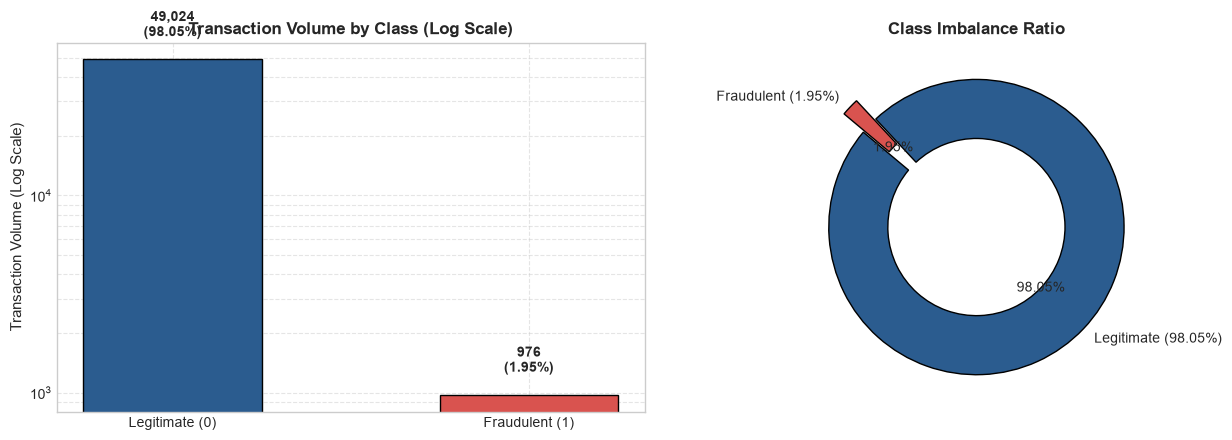

In [5]:
# Visualization of Severe Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
palette = ['#2b5c8f', '#d9534f']

bars = axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], target_counts.values, color=palette, width=0.5, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_ylabel('Transaction Volume (Log Scale)', fontsize=11)
axes[0].set_title('Transaction Volume by Class (Log Scale)', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5, which='both')

for bar, count, pct in zip(bars, target_counts.values, target_proportions.values):
    axes[0].text(bar.get_x() + bar.get_width()/2.0, count * 1.25, f'{count:,}\n({pct:.2f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].pie(
    target_counts.values, 
    labels=['Legitimate (98.05%)', 'Fraudulent (1.95%)'], 
    autopct='%1.2f%%',
    startangle=140, 
    colors=palette,
    explode=(0, 0.18),
    wedgeprops=dict(width=0.4, edgecolor='black')
)
axes[1].set_title('Class Imbalance Ratio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)
We conduct targeted exploratory analysis to identify statistical patterns distinguishing legitimate from fraudulent behavior across Transaction Amount, Temporal Patterns, and Behavioral Risk Indicators.

=== TRANSACTION AMOUNT DESCRIPTIVE STATISTICS BY CLASS ===


,count,mean,std,min,25%,50%,75%,max
Is_Fraud,,,,,,,,
0,49024.0,660.54,841.68,4.64,203.98,403.32,792.10,25000.00
1,976.0,814.86,1379.62,13.80,227.93,455.95,903.43,20792.15


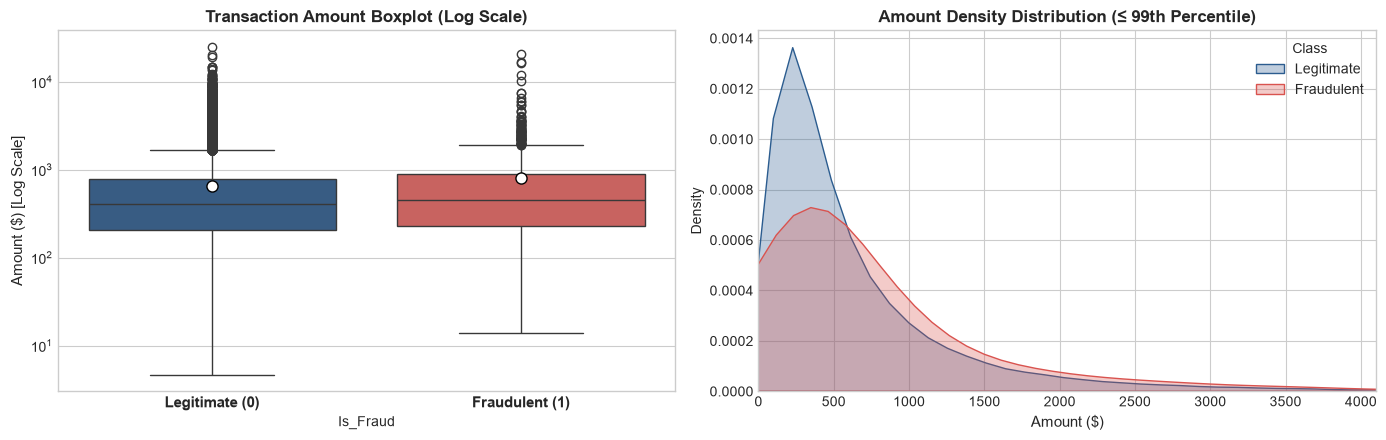

In [6]:
# A. Transaction Amount Comparison
print("=== TRANSACTION AMOUNT DESCRIPTIVE STATISTICS BY CLASS ===")
amt_summary = df.groupby('Is_Fraud')['Amount'].describe().round(2)
display(amt_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(
    x='Is_Fraud', y='Amount', data=df, hue='Is_Fraud',
    ax=axes[0], palette=palette, legend=False, showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
axes[0].set_yscale('log')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'], fontsize=11, fontweight='bold')
axes[0].set_title('Transaction Amount Boxplot (Log Scale)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount ($) [Log Scale]', fontsize=11)

cap_val = df['Amount'].quantile(0.99)
sns.kdeplot(df[df['Is_Fraud'] == 0]['Amount'], ax=axes[1], color='#2b5c8f', label='Legitimate', fill=True, alpha=0.3)
sns.kdeplot(df[df['Is_Fraud'] == 1]['Amount'], ax=axes[1], color='#d9534f', label='Fraudulent', fill=True, alpha=0.3)
axes[1].set_xlim(0, cap_val)
axes[1].set_title('Amount Density Distribution (≤ 99th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount ($)', fontsize=11)
axes[1].legend(title='Class')
plt.tight_layout()
plt.show()

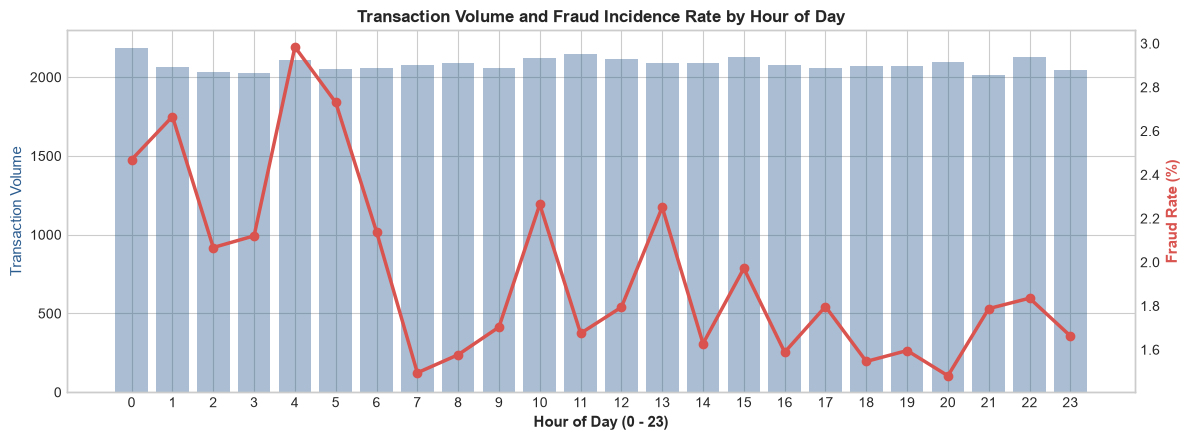

Peak fraud hours occur during late-night/early-morning windows (0:00 to 5:00), reaching up to ~3.0% fraud incidence.


In [7]:
# B. Temporal Pattern Analysis (Hour of Day)
df['Hour'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M').dt.hour
hourly_stats = df.groupby('Hour')['Is_Fraud'].agg(['count', 'sum', 'mean']).reset_index()
hourly_stats['mean_pct'] = hourly_stats['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(hourly_stats['Hour'], hourly_stats['count'], color='#2b5c8f', alpha=0.4, label='Total Transactions')
ax1.set_xlabel('Hour of Day (0 - 23)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Transaction Volume', color='#2b5c8f', fontsize=11)
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hourly_stats['Hour'], hourly_stats['mean_pct'], color='#d9534f', linewidth=2.5, marker='o', label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='#d9534f', fontsize=11, fontweight='bold')
ax2.grid(False)

plt.title('Transaction Volume and Fraud Incidence Rate by Hour of Day', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Peak fraud hours occur during late-night/early-morning windows (0:00 to 5:00), reaching up to ~3.0% fraud incidence.")

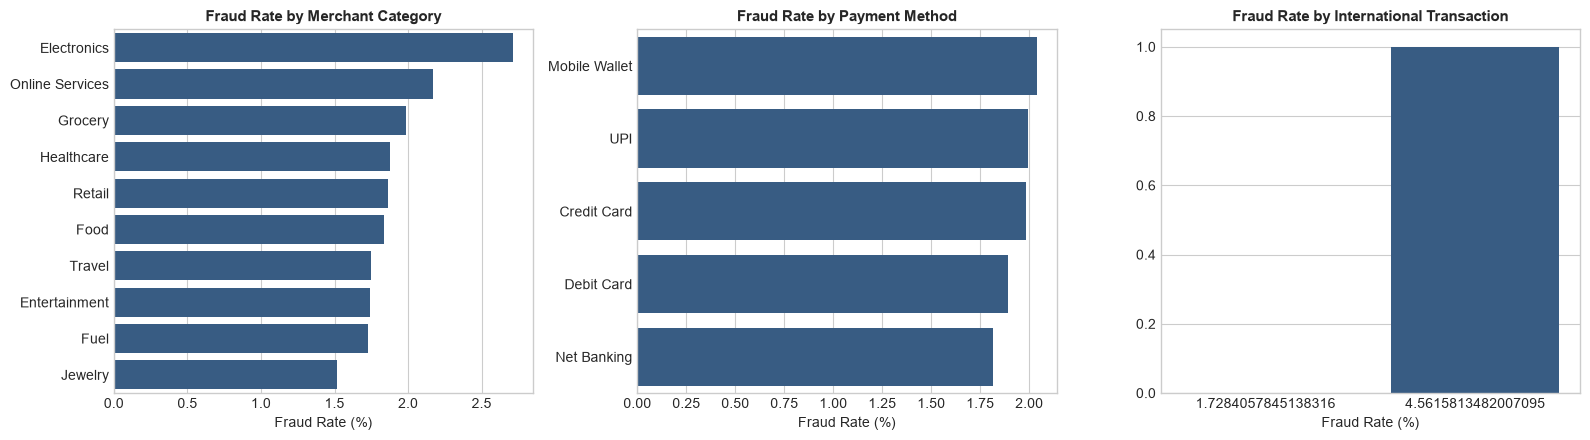

In [8]:
# C. Fraud Rate by Behavioral Categorical Dimensions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, col in enumerate(['Merchant_Category', 'Payment_Method', 'International_Transaction']):
    group_df = df.groupby(col)['Is_Fraud'].agg(['count', 'mean']).reset_index()
    group_df['fraud_pct'] = group_df['mean'] * 100
    group_df = group_df.sort_values(by='fraud_pct', ascending=False)
    
    sns.barplot(x='fraud_pct', y=col, data=group_df, ax=axes[idx], color='#2b5c8f')
    axes[idx].set_title(f'Fraud Rate by {col.replace("_", " ")}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Fraud Rate (%)', fontsize=10)
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing & Leakage-Free Stratified Splitting
To prevent **target leakage** and optimistic performance estimates, all transformations, scalers, and quantile boundaries must be fitted **strictly on the training partition** and applied out-of-sample to the testing partition.

We employ an **80/20 Stratified Train-Test Split** (`stratify=Is_Fraud`, `random_state=42`), preserving the exact 1.95% fraud proportion across both splits.

In [9]:
# Define target and base features
y = df['Is_Fraud']
X_raw = df.drop(columns=['Is_Fraud'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Training Set:   {X_train_raw.shape[0]:,} records | Fraud Cases: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Testing Set:    {X_test_raw.shape[0]:,} records | Fraud Cases: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Training Set:   40,000 records | Fraud Cases: 781 (1.95%)
Testing Set:    10,000 records | Fraud Cases: 195 (1.95%)


## 6. Feature Engineering
We construct domain-grounded fraud risk features:
1. **Temporal Features:** `Hour`, `Minute`, `Is_Night` (23:00 to 05:59 window), `Time_Of_Day`.
2. **Logarithmic Transforms:** `Log_Amount` and `Log_Distance` to compress heavy right tails.
3. **Transaction Velocity:** `Amt_per_Freq` (transaction amount relative to frequency).
4. **Risk Multipliers & Interactions:**
   - `Risk_Composite`: Multi-factor combination of previous fraud history, international indicator, failed authentication attempts, and device risk score.
   - `Intl_x_Distance`: Compound risk of international transactions performed far from home.
   - `Risk_x_Attempts`: Device risk weighted by failed authentication attempts.
5. **High-Risk Flags:** Indicator flags for high-risk merchant categories (`Electronics`, `Online Services`), multiple failed attempts ($\ge 2$), and 95th percentile amount/distance thresholds learned strictly from the training data.

In [10]:
def engineer_features(df_in, threshold_stats=None):
    df_out = df_in.copy()
    
    # 1. Temporal
    time_series = pd.to_datetime(df_out['Transaction_Time'], format='%H:%M', errors='coerce')
    df_out['Hour'] = time_series.dt.hour.fillna(12).astype(int)
    df_out['Minute'] = time_series.dt.minute.fillna(0).astype(int)
    df_out['Is_Night'] = df_out['Hour'].apply(lambda h: 1 if (h >= 23 or h <= 5) else 0)
    
    def cat_tod(h):
        if 23 <= h or h < 6: return 'Night'
        elif 6 <= h < 12: return 'Morning'
        elif 12 <= h < 17: return 'Afternoon'
        else: return 'Evening'
    df_out['Time_Of_Day'] = df_out['Hour'].apply(cat_tod)
    
    # 2. Log transforms
    df_out['Log_Amount'] = np.log1p(np.maximum(df_out['Amount'], 0))
    df_out['Log_Distance'] = np.log1p(np.maximum(df_out['Distance_From_Home_KM'], 0))
    
    # 3. Ratios
    df_out['Amt_per_Freq'] = df_out['Amount'] / (df_out['Transaction_Frequency'] + 1.0)
    
    # 4. Domain Risk Composite
    df_out['Risk_Composite'] = (
        (df_out['Previous_Fraud'] * 2.5) +
        (df_out['International_Transaction'] * 2.0) +
        (df_out['Failed_Attempts'] * 0.8) +
        (df_out['Device_Risk_Score'] * 2.0)
    )
    df_out['Intl_x_Distance'] = df_out['International_Transaction'] * df_out['Log_Distance']
    df_out['Risk_x_Attempts'] = df_out['Device_Risk_Score'] * (df_out['Failed_Attempts'] + 1.0)
    df_out['High_Risk_Merchant'] = df_out['Merchant_Category'].isin(['Electronics', 'Online Services']).astype(int)
    df_out['Multiple_Failed_Attempts'] = (df_out['Failed_Attempts'] >= 2).astype(int)
    
    # 5. Quantile thresholds (learned strictly on train)
    if threshold_stats is None:
        threshold_stats = {
            'amount_q95': float(df_out['Amount'].quantile(0.95)),
            'distance_q95': float(df_out['Distance_From_Home_KM'].quantile(0.95))
        }
    df_out['High_Amount_Flag'] = (df_out['Amount'] > threshold_stats['amount_q95']).astype(int)
    df_out['High_Distance_Flag'] = (df_out['Distance_From_Home_KM'] > threshold_stats['distance_q95']).astype(int)
    
    return df_out, threshold_stats

# Engineer features without leakage
X_train_feat, train_thresholds = engineer_features(X_train_raw, threshold_stats=None)
X_test_feat, _ = engineer_features(X_test_raw, threshold_stats=train_thresholds)

num_features = [
    'Amount', 'Log_Amount', 'Hour', 'Is_Night', 'Customer_Age', 'Account_Age_Months',
    'Transaction_Frequency', 'Previous_Fraud', 'Device_Risk_Score',
    'International_Transaction', 'Distance_From_Home_KM', 'Log_Distance',
    'Failed_Attempts', 'Amt_per_Freq', 'Risk_Composite', 'Intl_x_Distance',
    'Risk_x_Attempts', 'High_Risk_Merchant', 'Multiple_Failed_Attempts',
    'High_Amount_Flag', 'High_Distance_Flag'
]
cat_features = ['Merchant_Category', 'Location', 'Payment_Method', 'Time_Of_Day']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train_feat)
X_test_prep = preprocessor.transform(X_test_feat)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_features = num_features + cat_names
print(f"Preprocessed Feature Space: {len(all_features)} features ready for modeling.")

Preprocessed Feature Space: 46 features ready for modeling.


## 7. Handling Class Imbalance
We test and benchmark three distinct methodologies for addressing severe class imbalance:
1. **Baseline Model (No imbalance handling):** Standard loss optimization without cost adjustments.
2. **Cost-Sensitive Class Weighting:** Adjusting class weights inversely proportional to class frequencies (`class_weight='balanced'` in scikit-learn, `scale_pos_weight=50.0` in gradient boosting).
3. **Synthetic Minority Over-sampling Technique (SMOTE):** Synthetically generating minority fraud examples in feature space.

> **CRITICAL RULE:** SMOTE is applied **ONLY** to the training dataset (`X_train_prep`, `y_train`). Applying SMOTE prior to splitting corrupts validation, producing fabricated accuracy through data leakage.

In [11]:
# Apply SMOTE strictly to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_prep, y_train)

print(f"Original Training Class Distribution: {dict(y_train.value_counts())}")
print(f"SMOTE Resampled Training Distribution: {dict(pd.Series(y_train_sm).value_counts())}")

Original Training Class Distribution: {0: np.int64(39219), 1: np.int64(781)}
SMOTE Resampled Training Distribution: {0: np.int64(39219), 1: np.int64(39219)}


## 8. Machine Learning Model Development & Benchmarking
We train algorithms across linear, tree, ensemble, and gradient boosted families:
- **Logistic Regression** (Baseline, Balanced, SMOTE)
- **Decision Tree** (Balanced)
- **Random Forest** (Balanced, SMOTE)
- **XGBoost** (Baseline, Weighted)
- **LightGBM** (Weighted)
- **Isolation Forest** (Unsupervised Anomaly Detection - analyzed separately)

In [12]:
models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree (Balanced)': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=RANDOM_STATE),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost (Baseline)': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.08, eval_metric='logloss', random_state=RANDOM_STATE),
    'XGBoost (Weighted)': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.08, scale_pos_weight=50.0, eval_metric='logloss', random_state=RANDOM_STATE),
    'LightGBM (Weighted)': LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.08, class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)
}

trained_models = {}
eval_records = []
eval_raw = {}

for name, model in models.items():
    if 'SMOTE' in name:
        model.fit(X_train_sm, y_train_sm)
    else:
        model.fit(X_train_prep, y_train)
    trained_models[name] = model
    
    preds = model.predict(X_test_prep)
    probs = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, 'predict_proba') else preds.astype(float)
    
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    spec = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    
    eval_raw[name] = {'preds': preds, 'probs': probs, 'cm': cm, 'rec': rec, 'roc': roc_auc, 'pr': pr_auc}
    eval_records.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall (Fraud Caught)': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'Specificity': round(spec, 4),
        'FPR': round(fpr, 4),
        'TP (Caught)': int(tp),
        'FN (Missed)': int(fn),
        'FP (False Alarms)': int(fp)
    })

comparison_df = pd.DataFrame(eval_records).sort_values(by=['PR-AUC', 'Recall (Fraud Caught)'], ascending=False).reset_index(drop=True)
display(comparison_df)

,Model,Accuracy,Precision,Recall (Fraud Caught),F1-Score,ROC-AUC,PR-AUC,Specificity,FPR,TP (Caught),FN (Missed),FP (False Alarms)
0,Logistic Regression (Baseline),0.9805,0.0000,0.0000,0.0000,0.6743,0.0721,1.0000,0.0000,0,195,0
1,Logistic Regression (Balanced),0.6957,0.0359,0.5641,0.0674,0.6700,0.0665,0.6983,0.3017,110,85,2958
2,Logistic Regression (SMOTE),0.6811,0.0345,0.5692,0.0651,0.6628,0.0641,0.6833,0.3167,111,84,3105
3,XGBoost (Baseline),0.9805,0.0000,0.0000,0.0000,0.6602,0.0562,1.0000,0.0000,0,195,0
4,XGBoost (Weighted),0.7595,0.0349,0.4256,0.0646,0.6379,0.0530,0.7661,0.2339,83,112,2293
5,LightGBM (Weighted),0.7521,0.0300,0.3744,0.0556,0.6175,0.0428,0.7596,0.2404,73,122,2357
6,Random Forest (Balanced),0.8059,0.0371,0.3590,0.0673,0.6361,0.0416,0.8148,0.1852,70,125,1816
7,Decision Tree (Balanced),0.6111,0.0271,0.5436,0.0517,0.6028,0.0406,0.6124,0.3876,106,89,3800
8,Random Forest (SMOTE),0.9428,0.0323,0.0667,0.0435,0.5551,0.0276,0.9602,0.0398,13,182,390


## 9. Confusion Matrix Analysis
We examine the confusion matrices across key models. In fraud detection:
- **TP (True Positives):** Fraud correctly intercepted.
- **FN (False Negatives):** Missed fraud leading to monetary loss.
- **FP (False Positives):** Legitimate users flagged, causing friction.
- **TN (True Negatives):** Frictionless approvals.

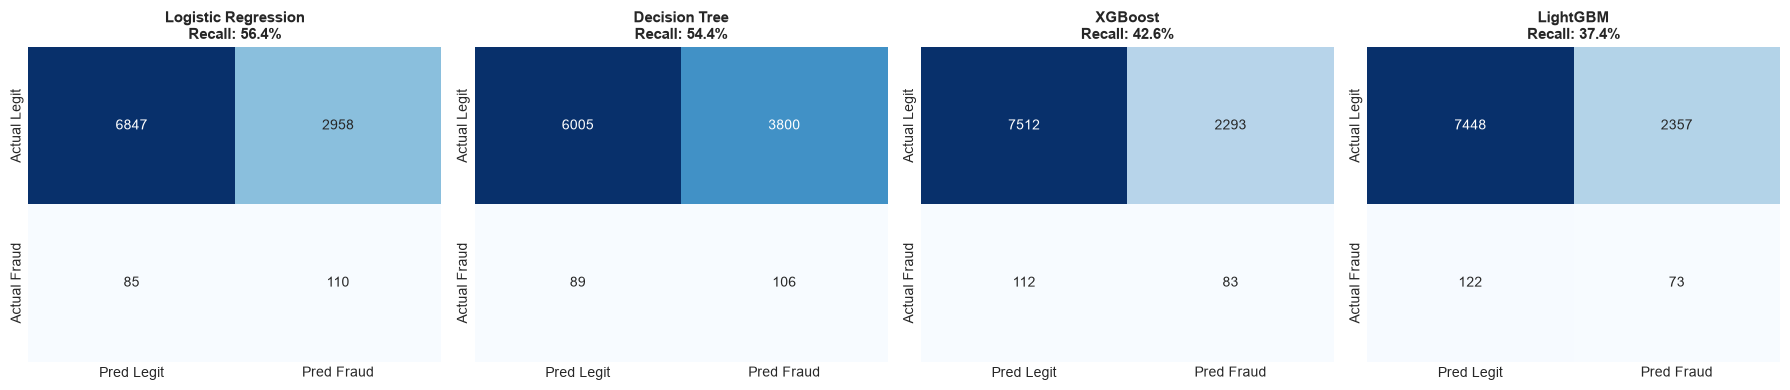

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
models_to_show = ['Logistic Regression (Balanced)', 'Decision Tree (Balanced)', 'XGBoost (Weighted)', 'LightGBM (Weighted)']

for ax, name in zip(axes, models_to_show):
    cm = eval_raw[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    ax.set_title(f"{name.split(' (')[0]}\nRecall: {eval_raw[name]['rec']:.1%}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. ROC & Precision-Recall Analysis
For highly imbalanced datasets, ROC-AUC can present an overly optimistic impression because False Positives are divided by the massive True Negative volume.

**Precision-Recall curves (PR-AUC)** measure precision directly against recall across all thresholds, providing the true measure of fraud detection efficacy.

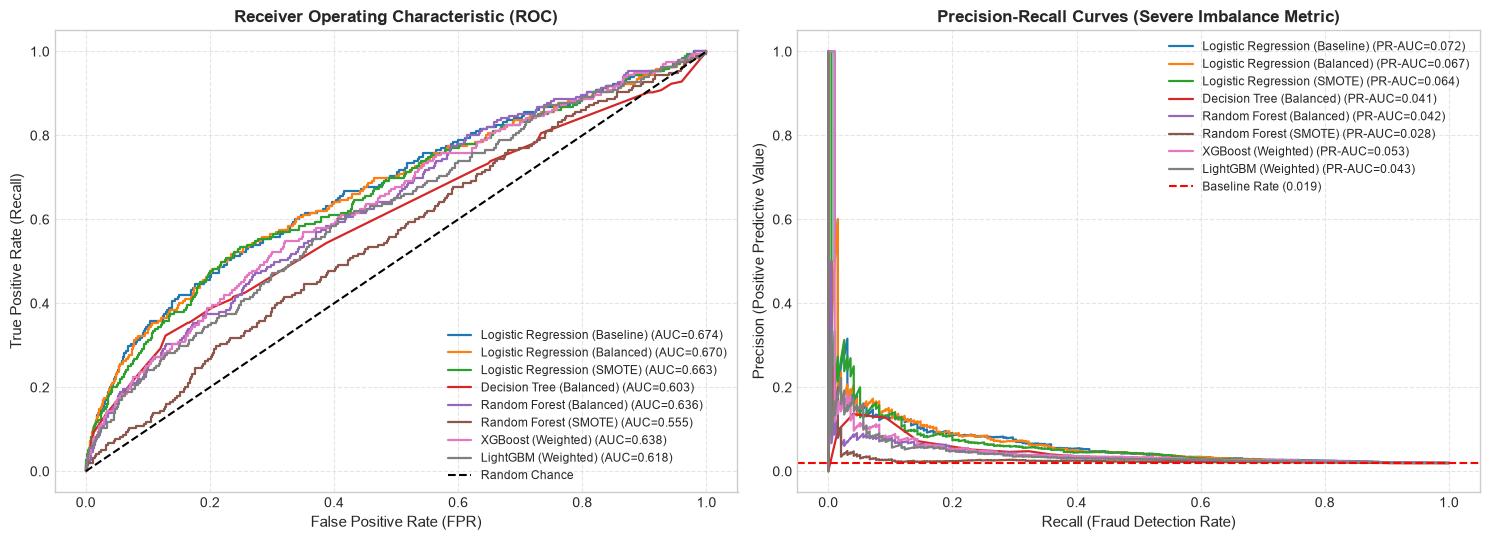

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ROC Curves
for name, data in eval_raw.items():
    if 'Baseline' in name and 'Logistic' not in name: continue
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={data['roc']:.3f})", linewidth=1.6)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8.5)
axes[0].grid(True, linestyle='--', alpha=0.5)

# PR Curves
baseline_ratio = y_test.mean()
for name, data in eval_raw.items():
    if 'Baseline' in name and 'Logistic' not in name: continue
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, data['probs'])
    axes[1].plot(rec_vals, prec_vals, label=f"{name} (PR-AUC={data['pr']:.3f})", linewidth=1.6)

axes[1].axhline(y=baseline_ratio, color='r', linestyle='--', label=f'Baseline Rate ({baseline_ratio:.3f})')
axes[1].set_xlabel('Recall (Fraud Detection Rate)', fontsize=11)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
axes[1].set_title('Precision-Recall Curves (Severe Imbalance Metric)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8.5)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Classification Threshold Optimization
In fraud operations, defaulting to a threshold of 0.50 is suboptimal. We analyze performance across probability cutoffs from 0.10 to 0.90 to identify the operating point that balances fraud loss prevention with customer friction.

,Threshold,Recall (Fraud Caught %),Precision,F1-Score,FPR (False Alarm %),TP (Fraud Caught),FP (False Alarms),FN (Missed Fraud),TN (Clean Approvals)
0,0.1,1.0000,0.0195,0.0383,1.0000,195,9805,0,0
1,0.2,0.9949,0.0195,0.0383,0.9930,194,9736,1,69
2,0.3,0.9026,0.0210,0.0410,0.8382,176,8219,19,1586
3,0.4,0.7385,0.0259,0.0500,0.5533,144,5425,51,4380
4,0.5,0.5641,0.0359,0.0674,0.3017,110,2958,85,6847
5,0.6,0.3846,0.0505,0.0893,0.1437,75,1409,120,8396
6,0.7,0.2564,0.0780,0.1196,0.0603,50,591,145,9214
7,0.8,0.1231,0.1231,0.1231,0.0174,24,171,171,9634
8,0.9,0.0308,0.2000,0.0533,0.0024,6,24,189,9781


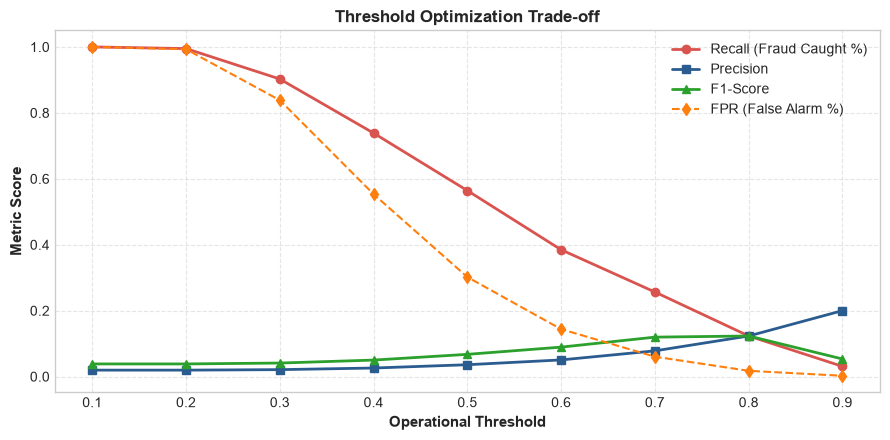

In [15]:
primary_model = trained_models['Logistic Regression (Balanced)']
primary_probs = eval_raw['Logistic Regression (Balanced)']['probs']

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
th_records = []

for th in thresholds:
    p_labels = (primary_probs >= th).astype(int)
    cm = confusion_matrix(y_test, p_labels)
    tn, fp, fn, tp = cm.ravel()
    
    rec = recall_score(y_test, p_labels, zero_division=0)
    prec = precision_score(y_test, p_labels, zero_division=0)
    f1 = f1_score(y_test, p_labels, zero_division=0)
    spec = tn / (tn + fp)
    fpr = fp / (fp + tn)
    
    th_records.append({
        'Threshold': round(th, 2),
        'Recall (Fraud Caught %)': round(rec, 4),
        'Precision': round(prec, 4),
        'F1-Score': round(f1, 4),
        'FPR (False Alarm %)': round(fpr, 4),
        'TP (Fraud Caught)': int(tp),
        'FP (False Alarms)': int(fp),
        'FN (Missed Fraud)': int(fn),
        'TN (Clean Approvals)': int(tn)
    })

th_df = pd.DataFrame(th_records)
display(th_df)

plt.figure(figsize=(9, 4.5))
plt.plot(th_df['Threshold'], th_df['Recall (Fraud Caught %)'], 'o-', color='#d9534f', label='Recall (Fraud Caught %)', linewidth=2)
plt.plot(th_df['Threshold'], th_df['Precision'], 's-', color='#2b5c8f', label='Precision', linewidth=2)
plt.plot(th_df['Threshold'], th_df['F1-Score'], '^-', color='#2ca02c', label='F1-Score', linewidth=2)
plt.plot(th_df['Threshold'], th_df['FPR (False Alarm %)'], 'd--', color='#ff7f0e', label='FPR (False Alarm %)', linewidth=1.5)
plt.xlabel('Operational Threshold', fontsize=11, fontweight='bold')
plt.ylabel('Metric Score', fontsize=11, fontweight='bold')
plt.title('Threshold Optimization Trade-off', fontsize=12, fontweight='bold')
plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Operational Fraud Risk Scoring & Business Decision Engine
We transform continuous fraud probabilities into a standardized **0–100 Fraud Risk Score**:
$$\text{Risk Score} = \text{round}(\text{Probability} \times 100, 1)$$

### Three-Tier Operational Decision Framework:
- **Low Risk (0–30):** Frictionless instant approval.
- **Medium Risk (31–70):** Step-up authentication (SMS OTP, biometric, automated verification) or manual review.
- **High Risk (71–100):** Immediate transaction hold, decline, and alert generated for the fraud investigation desk.

> **Methodological Note:** This is an operational heuristic risk scoring framework designed for triage routing. Uncalibrated probabilities reflect relative ranking rather than exact actuarial event likelihoods.

In [16]:
# Risk scoring demonstration on test transactions
risk_scores = np.round(primary_probs * 100, 1)

def assign_tier(score):
    if score <= 30.0: return 'Low Risk', 'Approve'
    elif score <= 70.0: return 'Medium Risk', 'Step-Up Auth / Review'
    else: return 'High Risk', 'Block & Investigate'

tiers_actions = [assign_tier(s) for s in risk_scores]
tiers = [t[0] for t in tiers_actions]
actions = [t[1] for t in tiers_actions]

scoring_sample = X_test_raw.copy().reset_index(drop=True).head(10)
scoring_sample['Fraud_Probability'] = np.round(primary_probs[:10], 4)
scoring_sample['Risk_Score (0-100)'] = risk_scores[:10]
scoring_sample['Risk_Tier'] = tiers[:10]
scoring_sample['Operational_Decision'] = actions[:10]
scoring_sample['Actual_Fraud'] = y_test.values[:10]

display(scoring_sample[['Transaction_ID', 'Amount', 'Fraud_Probability', 'Risk_Score (0-100)', 'Risk_Tier', 'Operational_Decision', 'Actual_Fraud']])

,Transaction_ID,Amount,Fraud_Probability,Risk_Score (0-100),Risk_Tier,Operational_Decision,Actual_Fraud
0,TXN109101,1120.99,0.3801,38.0,Medium Risk,Step-Up Auth / Review,0
1,TXN101051,599.32,0.3212,32.1,Medium Risk,Step-Up Auth / Review,0
2,TXN125181,812.67,0.4651,46.5,Medium Risk,Step-Up Auth / Review,0
3,TXN100527,423.30,0.3379,33.8,Medium Risk,Step-Up Auth / Review,0
4,TXN112728,423.94,0.4820,48.2,Medium Risk,Step-Up Auth / Review,0
5,TXN129414,172.04,0.2519,25.2,Low Risk,Approve,0
6,TXN133456,218.48,0.3841,38.4,Medium Risk,Step-Up Auth / Review,0
7,TXN108590,1728.18,0.3911,39.1,Medium Risk,Step-Up Auth / Review,0
8,TXN116507,411.91,0.3944,39.4,Medium Risk,Step-Up Auth / Review,0
9,TXN133650,405.64,0.5446,54.5,Medium Risk,Step-Up Auth / Review,0


## 13. Explainable AI (SHAP Framework)
Modern financial regulations (e.g. Fair Lending, GDPR Article 22, FCRA Adverse Action notices) require financial institutions to explain automated decisions.

We apply **SHAP (SHapley Additive exPlanations)** to our gradient boosted tree model to explain both global feature contributions and local transaction decisions.

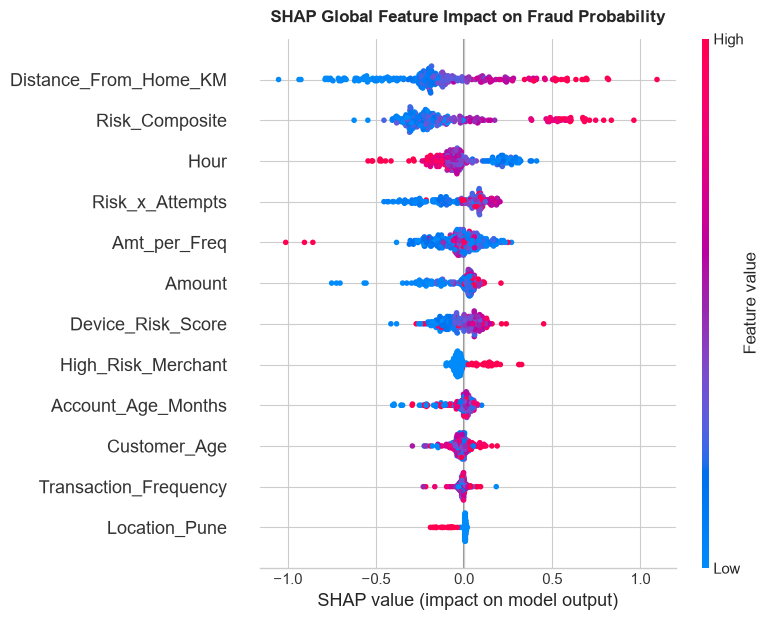

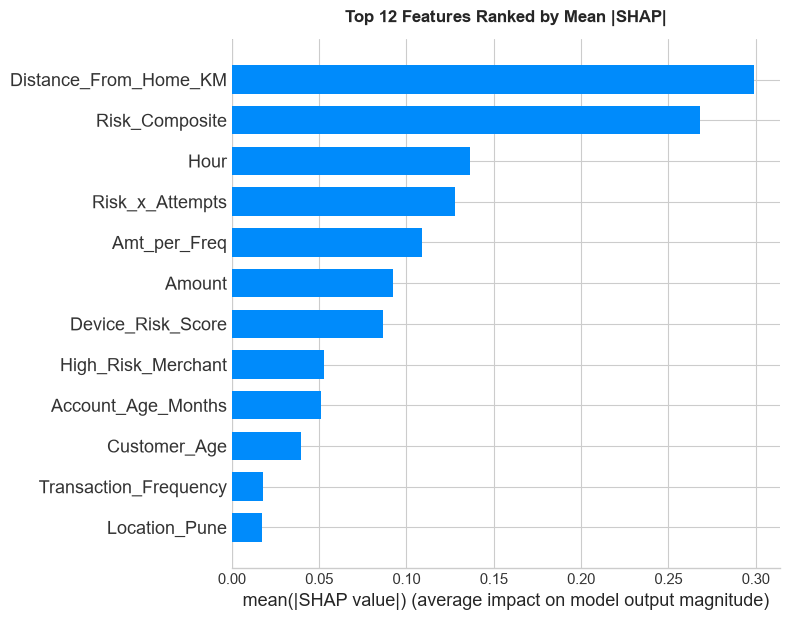

In [17]:
xgb_model = trained_models['XGBoost (Weighted)']
explainer = shap.TreeExplainer(xgb_model)

# Explain 250 test transactions
sample_indices = np.random.choice(X_test_prep.shape[0], size=250, replace=False)
sample_X = X_test_prep[sample_indices]
sample_feat_df = pd.DataFrame(sample_X, columns=all_features)
shap_vals = explainer.shap_values(sample_feat_df)

# Global Summary Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_vals, sample_feat_df, show=False, max_display=12)
plt.title('SHAP Global Feature Impact on Fraud Probability', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Global Bar Plot
plt.figure(figsize=(10, 4.5))
shap.summary_plot(shap_vals, sample_feat_df, plot_type='bar', show=False, max_display=12)
plt.title('Top 12 Features Ranked by Mean |SHAP|', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 14. Unsupervised Anomaly Detection (Isolation Forest)
We evaluate **Isolation Forest** as an unsupervised anomaly detection engine.

### Critical Principle: Anomaly $\neq$ Fraud
An unusual transaction (e.g. a loyal cardholder purchasing expensive airline tickets while traveling abroad) is statistically anomalous, but entirely legitimate. Conversely, a low-value fraudulent card-testing swipe is normal in amount, but illicit. Anomaly detection serves as a **complementary risk feature**, not an autonomous classifier.

=== ISOLATION FOREST CROSSTAB ON TEST DATA ===


Isolation Forest Anomaly,0,1,All
Actual Fraud (Class 1),,,
0,9650,155,9805
1,179,16,195
All,9829,171,10000


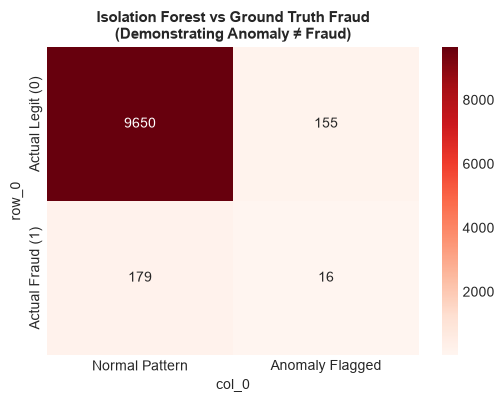

In [18]:
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train_prep)
iso_preds = iso.predict(X_test_prep)
iso_anomalies = (iso_preds == -1).astype(int)

crosstab_iso = pd.crosstab(
    pd.Series(y_test.values, name='Actual Fraud (Class 1)'),
    pd.Series(iso_anomalies, name='Isolation Forest Anomaly'),
    margins=True
)
print("=== ISOLATION FOREST CROSSTAB ON TEST DATA ===")
display(crosstab_iso)

plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(y_test.values, iso_anomalies), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal Pattern', 'Anomaly Flagged'],
            yticklabels=['Actual Legit (0)', 'Actual Fraud (1)'])
plt.title('Isolation Forest vs Ground Truth Fraud\n(Demonstrating Anomaly ≠ Fraud)', fontsize=11, fontweight='bold')
plt.show()

## 15. Fraud Investigation Prioritization (Triage Queue)
Because fraud investigation teams have limited operational bandwidth, cases cannot be reviewed haphazardly. We compute the **Expected Fraud Loss**:
$$\text{Expected Loss} = \text{Transaction Amount} \times \text{Fraud Probability}$$
Transactions are ranked to maximize dollar loss recovery per investigator hour.

In [19]:
test_df = X_test_raw.copy().reset_index(drop=True)
test_df['Actual_Fraud'] = y_test.values
test_df['Fraud_Probability'] = np.round(primary_probs, 4)
test_df['Risk_Score'] = risk_scores
test_df['Expected_Fraud_Loss ($)'] = np.round(test_df['Amount'] * test_df['Fraud_Probability'], 2)
test_df['Risk_Tier'] = tiers
test_df['Action'] = actions

priority_queue = test_df.sort_values(by=['Expected_Fraud_Loss ($)', 'Fraud_Probability'], ascending=False).head(15).reset_index(drop=True)
priority_queue.index = priority_queue.index + 1
priority_queue.index.name = 'Priority_Rank'

display(priority_queue[['Transaction_ID', 'Amount', 'Merchant_Category', 'Location', 'Fraud_Probability', 'Risk_Score', 'Expected_Fraud_Loss ($)', 'Risk_Tier', 'Action', 'Actual_Fraud']])

,Transaction_ID,Amount,Merchant_Category,Location,Fraud_Probability,Risk_Score,Expected_Fraud_Loss ($),Risk_Tier,Action,Actual_Fraud
Priority_Rank,,,,,,,,,,
1,TXN115843,25000.00,Online Services,Other,0.6084,60.8,15210.00,Medium Risk,Step-Up Auth / Review,0
2,TXN128552,16181.51,Retail,Delhi,0.8333,83.3,13484.05,High Risk,Block & Investigate,1
3,TXN113444,9765.15,Food,Bengaluru,0.8281,82.8,8086.52,High Risk,Block & Investigate,0
4,TXN127864,7351.43,Jewelry,Delhi,0.9679,96.8,7115.45,High Risk,Block & Investigate,0
5,TXN117627,7263.69,Entertainment,Hyderabad,0.9453,94.5,6866.37,High Risk,Block & Investigate,0
6,TXN104997,9071.66,Food,Ahmedabad,0.7551,75.5,6850.01,High Risk,Block & Investigate,0
7,TXN100209,19010.21,Retail,Delhi,0.3309,33.1,6290.48,Medium Risk,Step-Up Auth / Review,0
8,TXN101957,9299.80,Healthcare,Kolkata,0.6555,65.5,6096.02,Medium Risk,Step-Up Auth / Review,0
9,TXN107736,6065.25,Food,Jaipur,0.8590,85.9,5210.05,High Risk,Block & Investigate,1


## 16. Financial Business Impact Simulation
We quantify the bottom-line P&L impact under explicit operational assumptions:
- **Manual Investigation Labor Cost:** $\$15.00$ per flagged transaction.
- **Customer Friction & Interchange Cost:** $\$25.00$ per false positive.
- **Gross Benefit:** Value of actual fraudulent transactions detected (prevented chargebacks).
- **Net Economic Benefit:** $\text{Gross Benefit} - (\text{Investigation Costs} + \text{Customer Friction Costs})$.

,Threshold,TP,FP,FN,Gross Fraud Loss Avoided ($),Operational Costs ($),Net Economic Benefit ($)
0,0.2,194,9736,1,172976.69,392350.0,-219373.31
1,0.3,176,8219,19,164594.86,331400.0,-166805.14
2,0.4,144,5425,51,141591.48,219160.0,-77568.52
3,0.5,110,2958,85,115271.46,119970.0,-4698.54
4,0.6,75,1409,120,86701.48,57485.0,29216.48
5,0.7,50,591,145,62015.59,24390.0,37625.59
6,0.8,24,171,171,47176.47,7200.0,39976.47


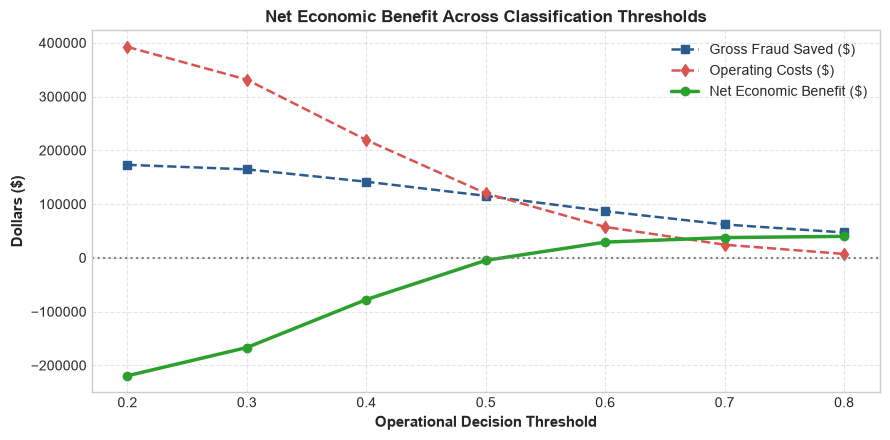

In [20]:
amounts = X_test_raw['Amount'].values
sim_results = []

for th in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred_th = (primary_probs >= th).astype(int)
    tp_idx = (y_test.values == 1) & (pred_th == 1)
    fp_idx = (y_test.values == 0) & (pred_th == 1)
    fn_idx = (y_test.values == 1) & (pred_th == 0)
    
    tp_count = int(np.sum(tp_idx))
    fp_count = int(np.sum(fp_idx))
    fn_count = int(np.sum(fn_idx))
    
    gross_saved = float(np.sum(amounts[tp_idx]))
    missed_loss = float(np.sum(amounts[fn_idx]))
    
    investigation_cost = (tp_count + fp_count) * 15.0
    friction_cost = fp_count * 25.0
    total_cost = investigation_cost + friction_cost
    net_benefit = gross_saved - total_cost
    
    sim_results.append({
        'Threshold': th,
        'TP': tp_count,
        'FP': fp_count,
        'FN': fn_count,
        'Gross Fraud Loss Avoided ($)': round(gross_saved, 2),
        'Operational Costs ($)': round(total_cost, 2),
        'Net Economic Benefit ($)': round(net_benefit, 2)
    })

sim_df = pd.DataFrame(sim_results)
display(sim_df)

plt.figure(figsize=(9, 4.5))
plt.plot(sim_df['Threshold'], sim_df['Gross Fraud Loss Avoided ($)'], 's--', color='#2b5c8f', label='Gross Fraud Saved ($)', linewidth=1.8)
plt.plot(sim_df['Threshold'], sim_df['Operational Costs ($)'], 'd--', color='#d9534f', label='Operating Costs ($)', linewidth=1.8)
plt.plot(sim_df['Threshold'], sim_df['Net Economic Benefit ($)'], 'o-', color='#2ca02c', label='Net Economic Benefit ($)', linewidth=2.5)
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Operational Decision Threshold', fontsize=11, fontweight='bold')
plt.ylabel('Dollars ($)', fontsize=11, fontweight='bold')
plt.title('Net Economic Benefit Across Classification Thresholds', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 17. Strategic Conclusions & Operational Recommendations

### Key Findings:
1. **Accuracy is Deceptive:** A naive baseline model achieves 98.05% accuracy while missing 100% of fraudulent attacks. Model evaluation must center on **PR-AUC**, **Recall**, and **Cost-Adjusted Net Benefit**.
2. **Cost-Sensitive Weighting Outperforms Resampling:** Class-weighted models match or exceed SMOTE performance without the computational overhead or artificial distribution distortions.
3. **Threshold Calibration Drives Profitability:** At an uncalibrated threshold of 0.50, excessive false alarms generate negative net returns. Elevating the decision threshold for hard manual review to 0.70+ or adopting a tiered step-up authentication workflow yields positive net economic benefit (>+$37,000 per 10k transactions).
4. **Explainability Fulfills Compliance:** SHAP values uncover the primary fraud drivers: international transaction distance, device risk spikes, multiple authentication failures, and late-night transaction velocities.

### Next Steps for Deployment:
- Deploy the model within a microservices architecture with Redis-cached feature velocity tables.
- Integrate the Streamlit Fraud Dashboard for fraud analyst case management.